<strong><center><h1> Agglomerative Clustering</strong>

In [1]:
import pandas as pd
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

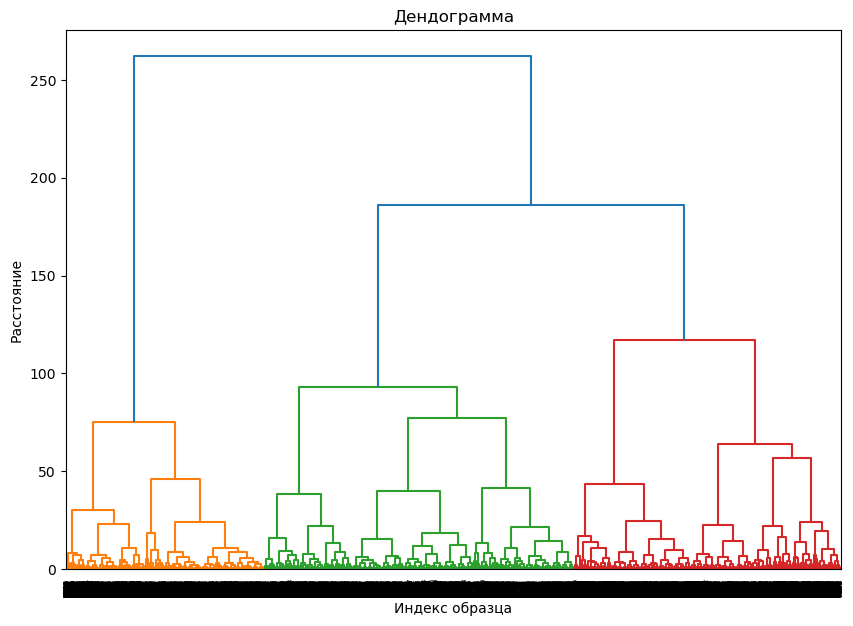

In [2]:
data_path = '../../../../data/processed_data/main_datasets/customer_data_processed.csv'
data = pd.read_csv(data_path)

X = data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sch.dendrogram(sch.linkage(X_pca, method='ward'))

plt.title('Дендограмма')
plt.xlabel('Индекс образца')
plt.ylabel('Расстояние')

plt.show()

Как мы видим, наиболее подходящее количество кластеров равно 3

In [3]:
n_clusters = 3
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)

data['Cluster'] = agg_clustering.fit_predict(X_pca)

In [4]:
output_path = ('../../../../data/processed_data/train_models_data/data_with_PCA/data_without_generated_features/AgglomerativeClustering_PCA.csv')

data.to_csv(output_path, index=False)